In [1]:
# =============================================
# Titanic Survival Prediction
# Kaggle Competition — Project 11 Part B
# Prajwal Kondala | IIT KGP → AI/ML Engineer
# May 2026
# =============================================

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported!")

All libraries imported!


In [3]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/competitions/titanic/train.csv
/kaggle/input/competitions/titanic/test.csv
/kaggle/input/competitions/titanic/gender_submission.csv


In [4]:
# Titanic datasets
train = pd.read_csv('/kaggle/input/competitions/titanic/train.csv')
test  = pd.read_csv('/kaggle/input/competitions/titanic/test.csv')

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("\nFirst 5 rows:")
train.head()

Train shape: (891, 12)
Test shape: (418, 11)

First 5 rows:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
print("Missing Values in Train:")
print(train.isnull().sum())
print("\nSurvival Rate:")
print(train['Survived'].value_counts())
print(f"\nOverall survival rate: {train['Survived'].mean():.1%}")

Missing Values in Train:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Survival Rate:
Survived
0    549
1    342
Name: count, dtype: int64

Overall survival rate: 38.4%


In [6]:
def prepare_features(df):
    df = df.copy()
    
    # Fill missing values
    df['Age']      = df['Age'].fillna(df['Age'].median())
    df['Fare']     = df['Fare'].fillna(df['Fare'].median())
    df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
    
    # Encode gender
    df['Sex'] = (df['Sex'] == 'male').astype(int)
    
    # Encode Embarked
    df['Embarked'] = df['Embarked'].map({'S':0, 'C':1, 'Q':2})
    
    # Family size feature
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
    
    # Is alone?
    df['IsAlone'] = (df['FamilySize'] == 1).astype(int)
    
    # Select features
    features = ['Pclass', 'Sex', 'Age', 'Fare',
                'Embarked', 'FamilySize', 'IsAlone']
    
    return df[features]

X      = prepare_features(train)
y      = train['Survived']
X_test = prepare_features(test)

print("Features shape:", X.shape)
print("Test shape:", X_test.shape)
print("\nFeatures used:", list(X.columns))

Features shape: (891, 7)
Test shape: (418, 7)

Features used: ['Pclass', 'Sex', 'Age', 'Fare', 'Embarked', 'FamilySize', 'IsAlone']


In [7]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("\nTrain survival rate:", y_train.mean().round(3))
print("Val survival rate:", y_val.mean().round(3))

X_train shape: (712, 7)
X_val shape: (179, 7)

Train survival rate: 0.383
Val survival rate: 0.385


In [8]:
# Train all ensemble models
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Decision Tree'      : DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost'            : XGBClassifier(n_estimators=100, learning_rate=0.1,
                                         max_depth=3, random_state=42,
                                         eval_metric='logloss', verbosity=0),
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    val_pred = model.predict(X_val)
    acc = accuracy_score(y_val, val_pred)
    cv  = cross_val_score(model, X, y, cv=5, scoring='accuracy').mean()
    results[name] = {'Accuracy': round(acc, 4), 'CV Score': round(cv, 4)}
    print(f"{name:<25} Accuracy: {acc:.4f} | CV Score: {cv:.4f}")

Logistic Regression       Accuracy: 0.7933 | CV Score: 0.7913
Decision Tree             Accuracy: 0.7598 | CV Score: 0.8171
Random Forest             Accuracy: 0.8101 | CV Score: 0.8036
XGBoost                   Accuracy: 0.7933 | CV Score: 0.8216


In [9]:
# XGBoost — best CV score!
best_model = models['XGBoost']

# Predict on test set
test_pred = best_model.predict(X_test)

# Create submission file
submission = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Survived'   : test_pred
})

submission.to_csv('submission.csv', index=False)
print("Submission file created!")
print(f"Shape: {submission.shape}")
print(f"\nSurvival predictions:")
print(submission['Survived'].value_counts())

Submission file created!
Shape: (418, 2)

Survival predictions:
Survived
0    284
1    134
Name: count, dtype: int64


Feature Importance — XGBoost:
   Feature  Importance
       Sex    0.583313
    Pclass    0.202461
  Embarked    0.059884
       Age    0.053315
FamilySize    0.053238
      Fare    0.047789
   IsAlone    0.000000


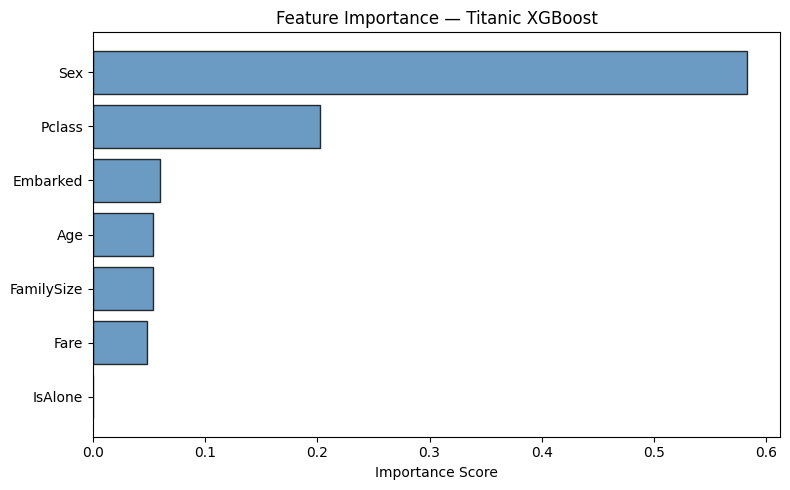

Chart saved!


In [10]:
# Feature importance from XGBoost!
feat_imp = pd.DataFrame({
    'Feature'   : X_train.columns,
    'Importance': best_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("Feature Importance — XGBoost:")
print(feat_imp.to_string(index=False))

# Plot
plt.figure(figsize=(8, 5))
plt.barh(feat_imp['Feature'], feat_imp['Importance'],
         color='steelblue', edgecolor='black', alpha=0.8)
plt.xlabel('Importance Score')
plt.title('Feature Importance — Titanic XGBoost')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight')
plt.show()
print("Chart saved!")

In [11]:
# Model Comparison Summary
print("=" * 55)
print(f"{'Model':<25} {'Val Accuracy':>12} {'CV Score':>12}")
print("-" * 55)
for name, scores in results.items():
    print(f"{name:<25} {scores['Accuracy']:>12.4f} {scores['CV Score']:>12.4f}")
print("=" * 55)
print("\nWinner → XGBoost (Best CV Score: 0.8216)")
print("Primary metric → CV Score (more reliable than single split!)")

Model                     Val Accuracy     CV Score
-------------------------------------------------------
Logistic Regression             0.7933       0.7913
Decision Tree                   0.7598       0.8171
Random Forest                   0.8101       0.8036
XGBoost                         0.7933       0.8216

Winner → XGBoost (Best CV Score: 0.8216)
Primary metric → CV Score (more reliable than single split!)
